# BinX AI & ML Internship
## Week 3 — Day 4: Trees, Forests, SVMs & k-NN

**Topics covered:**
- Decision Trees: rule-based, interpretable, prone to overfitting
- Random Forest: ensembles and feature importances
- Support Vector Machines and the margin
- k-Nearest Neighbors and lazy learning
- Comparing models fairly (No Free Lunch)

---

## 1. Before I Start: Why Do I Need More Models?

Today's plan is to learn Decision Trees, Random Forest, SVM, and k-NN. My first reaction was: I already have Logistic Regression from yesterday, and it worked — so why do I need four more ways to do the same thing?

I looked into it, and the answer is the **No Free Lunch Theorem**: no single algorithm wins on every dataset. Logistic Regression separates classes with one straight line. That works when the real pattern is close to linear — but not every relationship looks like that. Some patterns look more like a chain of rules: "if Glucose > 143 and Age > 28, then diabetes." A straight line can't represent that well.

While reading about this, I kept running into two terms that explain *why* models succeed or fail differently: **bias** and **variance**. I decided to understand those before touching any of today's models.

---

## 2. What I Found: Bias & Variance

- A model can be **too simple** to capture the real pattern — even in training data. This is **underfitting**, caused by **high bias**.
- A model can be **too complex**, capturing the real pattern *and* the random noise. This is **overfitting**, caused by **high variance**.

| | High Bias (Underfitting) | High Variance (Overfitting) |
|---|---|---|
| Training performance | Poor | Excellent |
| Test performance | Poor | Poor |

Instead of just reading about it, I ran a quick experiment to actually see this.

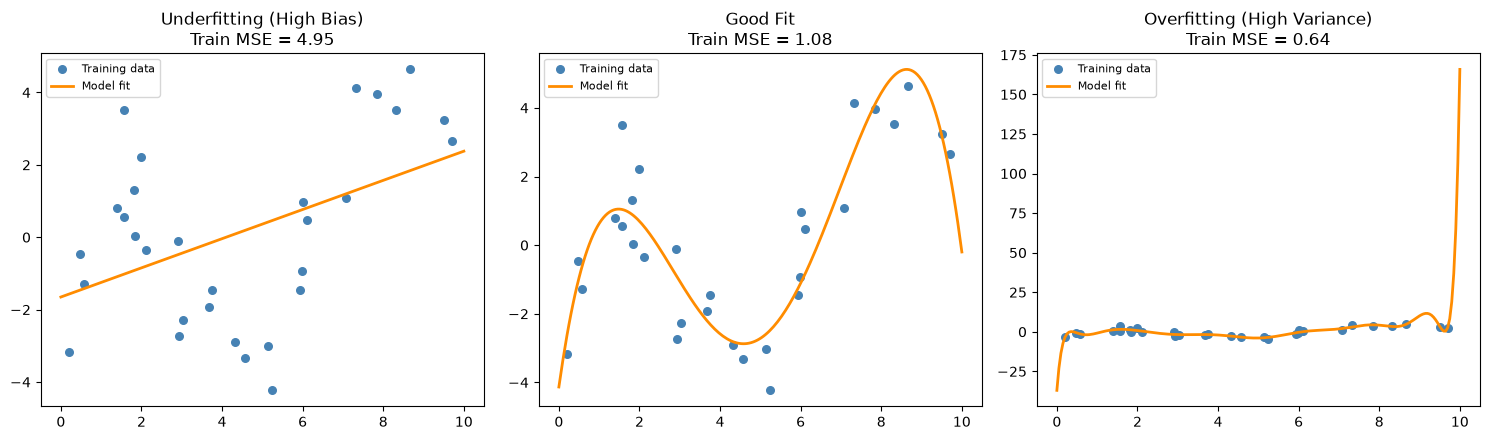

In [550]:
import numpy as np
import matplotlib.pyplot as plt

# Fix randomness so I get the same data every time I run this cell
np.random.seed(42)

# Generate 30 random x-values between 0 and 10
X_demo = np.sort(np.random.uniform(0, 10, 30))

# Create a curved (non-linear) signal + random noise
# This is synthetic — just to illustrate the concept, not real diabetes data
y_demo = (
    0.5 * (X_demo - 5)
    + 3 * np.sin(X_demo)
    + np.random.normal(0, 1.2, size=X_demo.shape)
)

# Dense x-axis for plotting smooth curves
X_smooth = np.linspace(0, 10, 200)

# Create three side-by-side plots to compare model complexity
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# degree controls how complex the model is:
# degree=1 → straight line, degree=4 → moderate curve, degree=15 → very wiggly
for ax, title, degree in zip(
    axes,
    ["Underfitting (High Bias)", "Good Fit", "Overfitting (High Variance)"],
    [1, 4, 15]
):
    # Fit a polynomial of the chosen degree to the training data
    coefficients = np.polyfit(X_demo, y_demo, degree)

    # Calculate predictions on the training points
    y_pred_train = np.polyval(coefficients, X_demo)

    # Measure how well the model fits training data
    train_mse = np.mean((y_demo - y_pred_train) ** 2)

    # Plot the original data points
    ax.scatter(X_demo, y_demo, s=30, color="steelblue", label="Training data")

    # Plot the learned curve (evaluated on the smooth x-axis)
    ax.plot(
        X_smooth,
        np.polyval(coefficients, X_smooth),
        color="darkorange",
        linewidth=2,
        label="Model fit"
    )

    ax.set_title(f"{title}\nTrain MSE = {train_mse:.2f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**What I see in this plot:**

The straight line on the left (degree=1) can't follow the curve in the data — it fails even on the training points it was built from. That's underfitting.

The wiggly curve on the right (degree=15) bends around every single point, including the noise. Its train MSE kept shrinking the more complex it got — which looks good until I remember that "train error" is not the same as "real-world performance." That's overfitting.

The middle curve (degree=4) finds the actual signal without memorizing the noise.

This is exactly why the train/test split matters: train error alone is misleading, and the only way to catch overfitting is checking performance on data the model never saw.

---

## 3. Decision Tree

A Decision Tree predicts by asking a sequence of yes/no questions about the features until it reaches a final decision. In my diabetes dataset, the tree learned rules like:

**"Is Glucose ≤ 143.5?"** → **"Is Age ≤ 28.5?"** → **"Predict: No Diabetes"**

Unlike Logistic Regression which learns a mathematical equation, a Decision Tree learns human-readable rules — I can literally follow the path and understand why the model made each prediction.

Its weakness is the same high-variance problem from Section 2: left alone, a tree keeps splitting until it classifies every training point correctly, including noise. `max_depth` limits how deep it can grow.

I'm reusing the exact same data, cleaning, and split from Day 3 (same `random_state=42`, same `stratify=y`) so today's comparison stays fair.

**Note:** the dataset file is `pimaindiansdiabetes.csv` located at the root of the Week 3 folder. I read it with explicit column names because the CSV has no header row.

In [551]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Column names — the CSV has no header row
cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv("data/pima-indians-diabetes.csv", header=None, names=cols)

# In this dataset, 0 means "missing reading", not an actual zero value
for col in ["Glucose", "BloodPressure", "BMI"]:
    df = df[df[col] != 0]

# SkinThickness and Insulin have too many missing values to be useful
df = df.drop(columns=["SkinThickness", "Insulin"])

# Separate features (X) from the target label (y)
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# stratify=y keeps the same class ratio (roughly 34% diabetes) in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Class balance in test — No Diabetes: {sum(y_test==0)}, Diabetes: {sum(y_test==1)}")

Training set: 579 rows
Test set:     145 rows
Class balance in test — No Diabetes: 95, Diabetes: 50


---

### 3.1 First: Does Overfitting Actually Happen Here?

Before picking a `max_depth`, I want to see the bias-variance trade-off on my real data — not just the synthetic demo above. I'll compare an unrestricted tree vs. a depth-limited one, looking at both train F1 and test F1.

In [552]:
# Compare unrestricted tree (no depth limit) vs. depth-limited (max_depth=5)
for depth, label in [(None, "No limit  "), (5, "max_depth=5")]:

    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)

    # F1 on training data: how well did it memorize what it saw?
    train_f1 = f1_score(y_train, m.predict(X_train))

    # F1 on test data: how well does it work on new, unseen data?
    test_f1  = f1_score(y_test,  m.predict(X_test))

    print(f"{label} → train F1 = {train_f1:.2f},  test F1 = {test_f1:.2f}")

No limit   → train F1 = 1.00,  test F1 = 0.53
max_depth=5 → train F1 = 0.77,  test F1 = 0.55


**Output I got:**
```
No limit   → train F1 = 1.00,  test F1 = 0.53
max_depth=5 → train F1 = 0.77,  test F1 = 0.55
```

The unrestricted tree memorized every training example — including noise — and scored a perfect 1.00 on training data. On unseen data it dropped to 0.53, actually *worse* than the limited tree's 0.55. This is the high-variance problem from Section 2 on my real data, not a demo. I'm using `max_depth=5` from here on.

---

### 3.2 Training the Final Tree & Reading Its Output

In [553]:
# Train the final Decision Tree with a depth limit of 5
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

# Generate predictions on the unseen test set
tree_predictions = tree_model.predict(X_test)

# ── Confusion Matrix ──────────────────────────────────────────────────────────
# Rows = actual class, Columns = predicted class
# [[TN  FP]
#  [FN  TP]]
print("Confusion Matrix:")
print(confusion_matrix(y_test, tree_predictions))
print()

# ── Classification Report ─────────────────────────────────────────────────────
# Precision = of all predicted positive, how many were actually positive
# Recall    = of all actual positive, how many did I catch
# F1        = harmonic mean of precision and recall
# Support   = number of real samples in each class
print(classification_report(y_test, tree_predictions, target_names=["No Diabetes", "Diabetes"]))

Confusion Matrix:
[[74 21]
 [23 27]]

              precision    recall  f1-score   support

 No Diabetes       0.76      0.78      0.77        95
    Diabetes       0.56      0.54      0.55        50

    accuracy                           0.70       145
   macro avg       0.66      0.66      0.66       145
weighted avg       0.69      0.70      0.70       145



**Output I got:**
```
Confusion Matrix:
[[74 21]
 [23 27]]

              precision    recall  f1-score   support
 No Diabetes       0.76      0.78      0.77        95
    Diabetes       0.56      0.54      0.55        50
    accuracy                           0.70       145
```

**Reading the confusion matrix:**

|  | Predicted No Diabetes | Predicted Diabetes |
|---|---|---|
| **Actual No Diabetes** | 74  correct | 21  false alarm |
| **Actual Diabetes** | 23  missed | 27  correct |

The tree correctly identified 27 out of 50 diabetes cases (recall = 54%). It also falsely flagged 21 healthy patients as diabetic. In a medical context, missing a diabetes case (false negative) is usually more costly than a false alarm — so recall for class 1 is the number to watch.

---

### 3.3 Visualizing the Tree

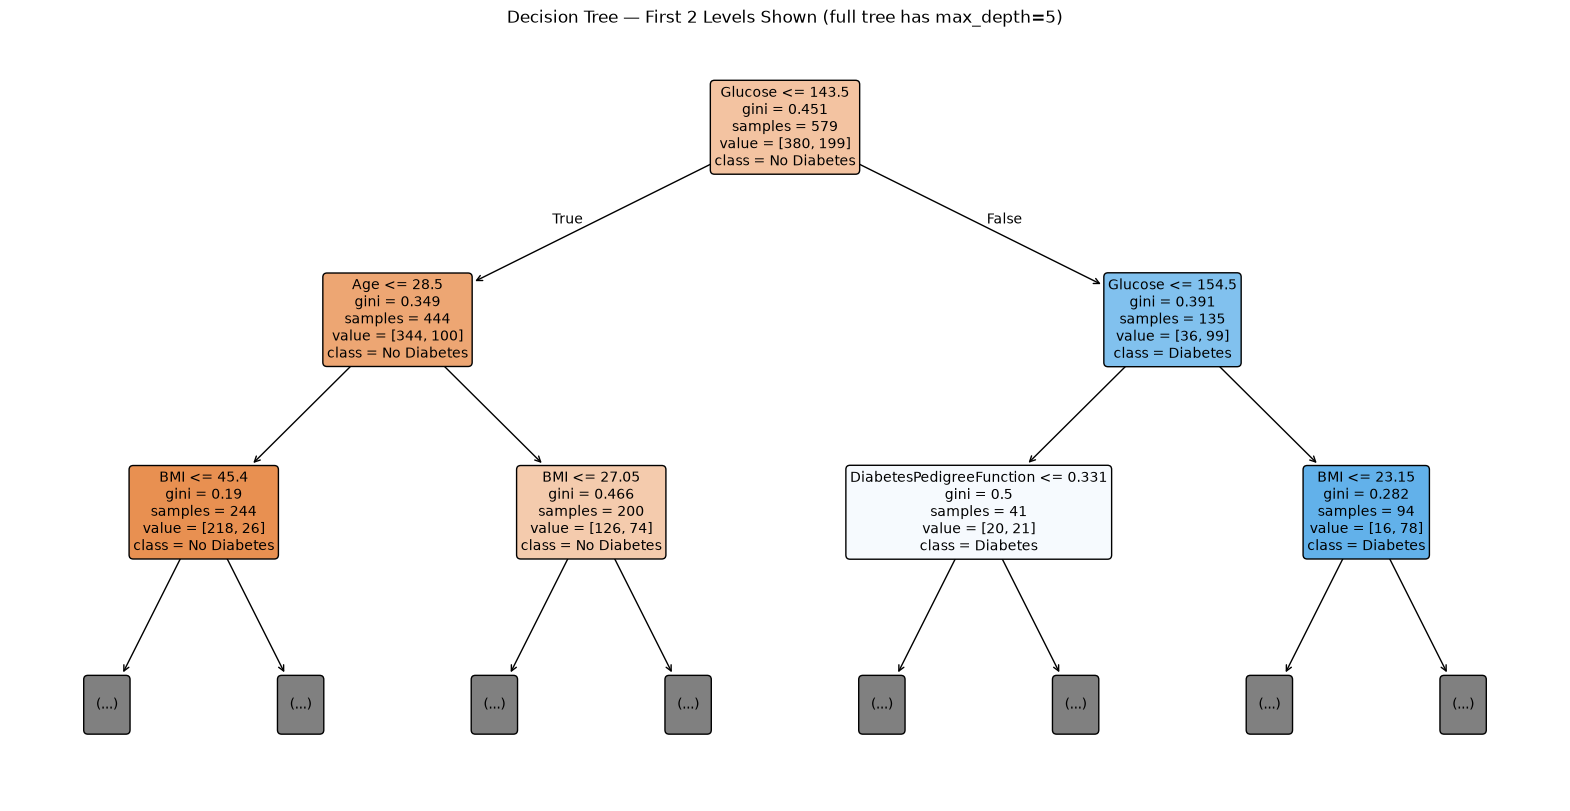

In [554]:
# Display only the first 2 levels — the full tree (max_depth=5) is too wide to read
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    max_depth=2,                          # show 2 levels even though tree goes to 5
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,                          # color nodes by majority class
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree — First 2 Levels Shown (full tree has max_depth=5)")
plt.show()

**Reading the diagram:**

Each box shows: the splitting question, the Gini score, how many samples reached that node, and the majority class.

The first question is **Glucose ≤ 143.5** — the tree found that this threshold separated the two classes better than any other feature at this point. Orange boxes lean toward "No Diabetes", blue boxes toward "Diabetes". The darker the color, the purer the node (lower Gini).

---

### 3.4 How Does the Split Get Chosen? (Gini Impurity)

I noticed "gini = 0.451" printed inside the root node and wanted to understand where that number comes from — so I worked it out by hand.

**Gini Impurity** measures how mixed the classes are at a node:

> Gini = 1 − (p₀² + p₁²)

- Pure node → only one class → Gini = **0**
- Perfectly mixed (50/50) → Gini = **0.5**

At every node, the tree tries every feature and every possible threshold, and picks the split that produces the **largest drop in Gini** (weighted by the number of samples in each child). That's the entire logic behind every question in my tree.

In [555]:
# Verify the root node Gini by hand using the numbers from the tree diagram
# Root node shows: value = [380, 199]  →  380 No Diabetes, 199 Diabetes

no_diabetes = 380
diabetes    = 199
total       = no_diabetes + diabetes

# Probability of each class at the root node
p0 = no_diabetes / total   # P(No Diabetes)
p1 = diabetes    / total   # P(Diabetes)

# Apply the Gini formula
gini_root = 1 - (p0**2 + p1**2)

print(f"p(No Diabetes) = {p0:.3f}")
print(f"p(Diabetes)    = {p1:.3f}")
print()
print(f"Hand-calculated Gini = {gini_root:.3f}")
print("Tree diagram showed:   0.451  ← should match")

p(No Diabetes) = 0.656
p(Diabetes)    = 0.344

Hand-calculated Gini = 0.451
Tree diagram showed:   0.451  ← should match


**Output I got:**
```
p(No Diabetes) = 0.656
p(Diabetes)    = 0.344

Hand-calculated Gini = 0.451
Tree diagram showed:   0.451  ← should match
```

It matches exactly. "gini = 0.451" is not a mysterious black-box score — it's literally `1 − (0.656² + 0.344²)` at that node. Every split I see in the diagram was chosen because it reduced this number more than any other option could.

---

### 3.5 Decision Tree Algorithms: CART vs ID3 vs C4.5

"Decision Tree" is the general idea — split data by asking questions. Several different algorithms implement this idea differently:

| Algorithm | Splitting Measure | Notes |
|---|---|---|
| ID3 | Entropy + Information Gain | Classification only, categorical features |
| C4.5 | Gain Ratio | Handles continuous features better than ID3 |
| **CART** | **Gini (classification) / MSE (regression)** | **scikit-learn's implementation** |

scikit-learn uses **CART**, which is why:
- Splits are always binary (exactly 2 branches per node)
- The default criterion is Gini for classification
- `DecisionTreeRegressor` uses the same algorithm with MSE instead of Gini

---

### 3.6 Feature Importance

`feature_importances_` sums up how much each feature reduced Gini across the whole tree. It's a measure of statistical usefulness to *this model on this dataset* — not a causal or medical explanation. On a different sample, or with different preprocessing, the ranking could shift.

In [556]:
# Build a ranked table of how much each feature contributed to splitting decisions
feature_importance_tree = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": tree_model.feature_importances_   # values sum to 1.0
}).sort_values(by="Importance", ascending=False)

feature_importance_tree

,Feature,Importance
1,Glucose,0.512397
3,BMI,0.177582
5,Age,0.142710
4,DiabetesPedigreeFunction,0.133958
0,Pregnancies,0.033353
2,BloodPressure,0.000000


**Output I got:**
```
Feature                   Importance
Glucose                     0.512
BMI                         0.178
Age                         0.143
DiabetesPedigreeFunction    0.134
Pregnancies                 0.033
BloodPressure               0.000
```

Glucose accounts for ~51% of all impurity reduction in the tree — which lines up with it being the very first question at the root. BloodPressure scored exactly **0.0**: the tree never found a threshold on it worth splitting on, even though it's still in the feature set.

---

### 3.7 Why Doesn't Decision Tree Need Feature Scaling?

Logistic Regression combines all features into one weighted sum: `w₁·Glucose + w₂·BMI + w₃·Age + ...` If features are on very different scales (Glucose in the hundreds, DiabetesPedigreeFunction under 3), the large-scale features dominate the weights unless I scale first.

A Decision Tree never combines features like that. Every question is a single threshold test on **one feature at a time**: "Is Glucose ≤ 143.5?" doesn't care what scale BMI is on. That's why I didn't use `StandardScaler` here — unlike SVM and k-NN later, which both rely on distance calculations across all features at once.

---

### 3.8 Does More Depth Always Help?

Instead of just saying "deeper trees overfit," I swept `max_depth` from 1 to 15 and tracked train F1 vs. test F1 at every value.

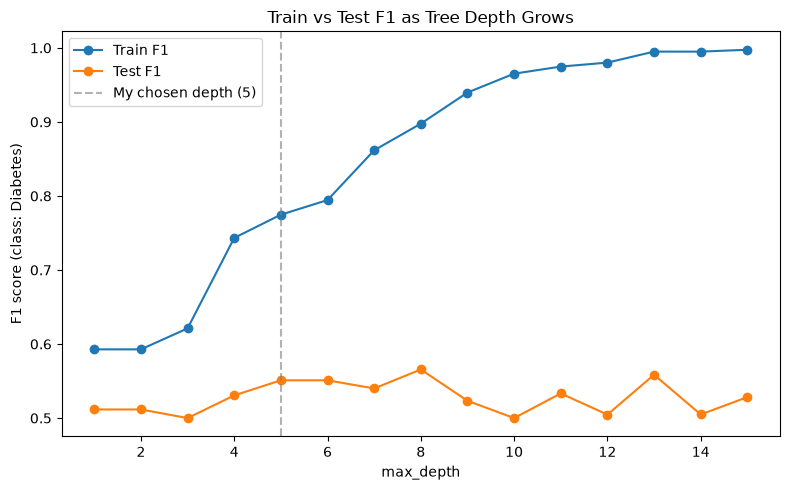

In [557]:
depths       = list(range(1, 16))   # test depths 1 through 15
train_scores = []                   # train F1 at each depth
test_scores  = []                   # test F1 at each depth

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)

    # Record how performance changes as complexity increases
    train_scores.append(f1_score(y_train, m.predict(X_train)))
    test_scores.append(f1_score(y_test,  m.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker='o', label='Train F1')
plt.plot(depths, test_scores,  marker='o', label='Test F1')

# Mark my chosen depth for reference
plt.axvline(x=5, color='gray', linestyle='--', alpha=0.6, label='My chosen depth (5)')

plt.xlabel('max_depth')
plt.ylabel('F1 score (class: Diabetes)')
plt.title('Train vs Test F1 as Tree Depth Grows')
plt.legend()
plt.tight_layout()
plt.show()

**What I see:** Train F1 climbs steadily toward 1.00 — the tree just keeps memorizing. Test F1 doesn't follow: it bounces between 0.50 and 0.57 no matter the depth. The noise is real — my test set has only 145 rows, so a few different predictions can swing F1 by several points. The takeaway isn't "depth 8 is the single best value" — it's that past a certain point, adding depth stops helping generalization at all.

---

## 4. Random Forest

A single Decision Tree overfits easily — small changes in training data can produce a completely different tree. Random Forest fixes this by training many trees and combining their votes.

The core idea: instead of trusting one imperfect tree, ask 100 different trees and take the majority vote. Individual errors cancel out across the ensemble.

---

### 4.1 How It Works: Bagging + Random Feature Selection

Random Forest adds two sources of randomness that a single tree doesn't have:

**Bagging (Bootstrap Aggregating):** each tree is trained on a different random sample of the data, drawn *with replacement*. No two trees see exactly the same rows — so they make different mistakes.

**Random feature selection:** at each split, instead of considering all features, each tree sees only a random subset (default: √number_of_features). This prevents the strongest feature (Glucose) from dominating every single tree, forcing them to be diverse.

Together these reduce variance without significantly increasing bias.

---

In [558]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators = number of trees in the forest
# random_state = makes the sampling reproducible
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Final prediction = majority vote across all 100 trees
rf_predictions = rf_model.predict(X_test)

# Same output format as the tree, so I can compare directly
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))
print()
print(classification_report(y_test, rf_predictions, target_names=["No Diabetes", "Diabetes"]))

Confusion Matrix:
[[77 18]
 [19 31]]

              precision    recall  f1-score   support

 No Diabetes       0.80      0.81      0.81        95
    Diabetes       0.63      0.62      0.63        50

    accuracy                           0.74       145
   macro avg       0.72      0.72      0.72       145
weighted avg       0.74      0.74      0.74       145



**Output I got:**
```
Confusion Matrix:
[[77 18]
 [19 31]]

              precision    recall  f1-score   support
 No Diabetes       0.80      0.81      0.81        95
    Diabetes       0.63      0.62      0.63        50
    accuracy                           0.74       145
```

**Compared to the single tree:**
- Diabetes F1: 0.55 (single tree) → **0.63** (Random Forest)
- Correctly caught diabetes cases: 27 → **31**
- False alarms: 21 → **18**

Same training data, same split — just 100 trees instead of one.

---

### 4.2 Feature Importance in Random Forest

Unlike a single tree where one wrong split can cascade everywhere, Random Forest averages importance across 100 trees — making these values more stable. Each feature also gets more chances to contribute, since it won't always compete against Glucose at every node.

                 Feature  Importance
                 Glucose    0.296877
                     BMI    0.189761
                     Age    0.163928
DiabetesPedigreeFunction    0.161268
           BloodPressure    0.094775
             Pregnancies    0.093390



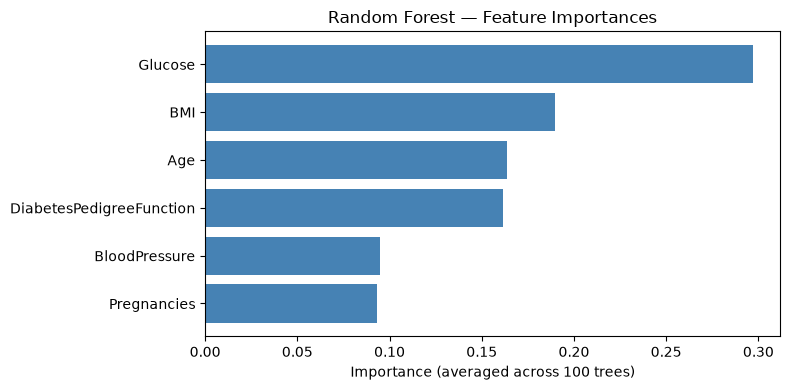

In [559]:
# Feature importances averaged across all 100 trees
feature_importance_rf = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": rf_model.feature_importances_   # averaged, so more stable than single tree
}).sort_values(by="Importance", ascending=False)

print(feature_importance_rf.to_string(index=False))
print()

# Horizontal bar chart — easier to scan than a table
fi_sorted = feature_importance_rf.sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(fi_sorted["Feature"], fi_sorted["Importance"], color="steelblue")
plt.xlabel("Importance (averaged across 100 trees)")
plt.title("Random Forest — Feature Importances")
plt.tight_layout()
plt.show()

**Output I got:**
```
Feature                   Importance
Glucose                     0.297
BMI                         0.190
Age                         0.164
DiabetesPedigreeFunction    0.161
BloodPressure               0.095
Pregnancies                 0.093
```

Glucose is still on top, but its dominance dropped from 0.51 (single tree) to 0.30. The other features get more of a say because each tree only sees a random subset of features at each split. BloodPressure is no longer 0.0 — some trees that didn't have Glucose available at a node used it instead.

---

### 4.3 How Do the Hyperparameters Actually Affect Performance?

Two key parameters to test on real data before assuming defaults are fine.

In [560]:
# ── Experiment 1: Number of Trees (n_estimators) ─────────────────────────────
print("=== How many trees? ===")
for trees in [10, 50, 100, 200]:
    m = RandomForestClassifier(n_estimators=trees, random_state=42)
    m.fit(X_train, y_train)
    # more trees = more averaging = lower variance (but diminishing returns)
    print(f"  n_estimators={trees:>3}: Test F1 = {f1_score(y_test, m.predict(X_test)):.3f}")

print()

# ── Experiment 2: Tree Depth (max_depth) ─────────────────────────────────────
print("=== Does tree depth inside the forest matter? ===")
for depth in [2, 5, 10, None]:
    m = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    # watch train vs test gap — does the forest still overfit with deep trees?
    print(
        f"  max_depth={str(depth):>4}: "
        f"Train F1 = {f1_score(y_train, m.predict(X_train)):.3f},  "
        f"Test F1 = {f1_score(y_test,  m.predict(X_test)):.3f}"
    )

=== How many trees? ===
  n_estimators= 10: Test F1 = 0.568
  n_estimators= 50: Test F1 = 0.612
  n_estimators=100: Test F1 = 0.626
  n_estimators=200: Test F1 = 0.646

=== Does tree depth inside the forest matter? ===
  max_depth=   2: Train F1 = 0.640,  Test F1 = 0.578
  max_depth=   5: Train F1 = 0.773,  Test F1 = 0.560
  max_depth=  10: Train F1 = 0.990,  Test F1 = 0.574
  max_depth=None: Train F1 = 1.000,  Test F1 = 0.626


**Output I got:**
```
=== How many trees? ===
  n_estimators= 10: Test F1 = 0.568
  n_estimators= 50: Test F1 = 0.612
  n_estimators=100: Test F1 = 0.626
  n_estimators=200: Test F1 = 0.646

=== Does tree depth inside the forest matter? ===
  max_depth=   2: Train F1 = 0.640,  Test F1 = 0.578
  max_depth=   5: Train F1 = 0.773,  Test F1 = 0.560
  max_depth=  10: Train F1 = 0.990,  Test F1 = 0.574
  max_depth=None: Train F1 = 1.000,  Test F1 = 0.626
```

**n_estimators:** more trees consistently helped — improvement slows down but never reverses. This is different from a single tree: adding depth to one tree eventually hurts, but adding more trees to a forest only helps (just with diminishing returns).

**max_depth:** even fully grown trees (None) gave a good test F1 of 0.626. In a single tree that was a disaster (0.53). The forest is more forgiving of individual tree overfitting because each tree's errors are partly uncorrelated and cancel in the vote.

---

## 5. Support Vector Machine (SVM)

Decision Tree and Random Forest think in terms of rules and regions. SVM thinks geometrically: it searches for the decision boundary that **maximizes the margin** — the gap between the closest points of each class.

A wider margin generally means better generalization. The boundary is defined entirely by the training points that sit closest to it — the **support vectors**. Points far away from the boundary have no influence on the model at all.

---

### 5.1 The Kernel Trick

A linear SVM only draws straight boundaries. Most real data isn't linearly separable. The **kernel trick** solves this: instead of explicitly transforming data into higher dimensions (which is expensive), a kernel function computes similarity between points *as if* that transformation had already happened.

The **RBF (Radial Basis Function) kernel** — scikit-learn's default — can draw curved, non-linear boundaries and works well on many real-world datasets.

---

### 5.2 Why Does SVM Need Feature Scaling?

SVM builds its boundary using **distances and dot products** across all features simultaneously. If Glucose is in the hundreds and DiabetesPedigreeFunction is under 3, Glucose will dominate all distance calculations — not because it's more important, but because its numbers are larger.

`StandardScaler` puts all features on the same scale before the distance math runs. I wrap it in a `Pipeline` so the scaler is always fit on training data only — no information leaks from the test set.

---

In [561]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Pipeline runs StandardScaler first, then SVC
# This ensures scaling parameters are learned from X_train only
svm_model = make_pipeline(
    StandardScaler(),                           # center and scale all features
    SVC(
        kernel="rbf",                           # RBF = curved, non-linear boundary
        probability=True,                       # allows predict_proba() if needed
        random_state=42
    )
)

svm_model.fit(X_train, y_train)

# Generate predictions using the boundary the SVM found
svm_predictions = svm_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_predictions))
print()
print(classification_report(y_test, svm_predictions, target_names=["No Diabetes", "Diabetes"]))

c:\Users\user\OneDrive\Desktop\BinX_AI_ML_Internship\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Confusion Matrix:
[[80 15]
 [23 27]]

              precision    recall  f1-score   support

 No Diabetes       0.78      0.84      0.81        95
    Diabetes       0.64      0.54      0.59        50

    accuracy                           0.74       145
   macro avg       0.71      0.69      0.70       145
weighted avg       0.73      0.74      0.73       145



**Output I got:**
```
Confusion Matrix:
[[80 15]
 [23 27]]

              precision    recall  f1-score   support
 No Diabetes       0.78      0.84      0.81        95
    Diabetes       0.64      0.54      0.59        50
    accuracy                           0.74       145
```

SVM is more conservative about predicting diabetes (only 42 total predicted vs 48 by RF), but when it does predict diabetes it's right more often (precision = 0.64 vs 0.63). The trade-off: it misses more actual diabetes cases (recall = 0.54 vs 0.62).

---

### 5.3 Does the Kernel Choice Actually Matter?

In [562]:
# Compare three different kernels on the same data
# Each kernel draws a different shape of decision boundary
for kernel in ["linear", "poly", "rbf"]:
    m = make_pipeline(
        StandardScaler(),
        SVC(kernel=kernel, random_state=42)     # same data, same split — only kernel changes
    )
    m.fit(X_train, y_train)
    print(f"  {kernel:>6}: Test F1 = {f1_score(y_test, m.predict(X_test)):.3f}")

  linear: Test F1 = 0.574
    poly: Test F1 = 0.487
     rbf: Test F1 = 0.587


**Output I got:**
```
  linear: Test F1 = 0.574
    poly: Test F1 = 0.487
     rbf: Test F1 = 0.587
```

`linear` found a decent straight boundary (0.574). `poly` struggled the most (0.487) — it adds flexibility in a specific structured way that doesn't fit this dataset's pattern. `rbf` performed best (0.587) — it's more general-purpose. This is another example of No Free Lunch: no kernel wins on every dataset, and testing is the only way to know.

---

## 6. k-Nearest Neighbors (k-NN)

k-NN is the simplest classifier in today's lineup, and I kept it for last because it introduces an idea that's completely different from everything else: **there is no training step.**

k-NN stores the entire training dataset and waits. When a new sample arrives, it finds the k closest training points, looks at their labels, and returns the majority class. All computation happens at prediction time, not training time. This is called **lazy learning**.

---

### 6.1 Lazy vs Eager Learning

| Model | When It "Learns" | Cost Paid At |
|---|---|---|
| Logistic Regression | Training — optimizes weights | Training time |
| Decision Tree | Training — builds rules | Training time |
| Random Forest | Training — builds 100 trees | Training time |
| SVM | Training — finds the margin | Training time |
| **k-NN** | **Never — stores the data** | **Prediction time** |

The trade-off: k-NN has almost no training cost, but every prediction requires comparing the new point to all training points — which gets slow as the dataset grows.

---

### 6.2 Why Does k-NN Need Feature Scaling?

k-NN defines "nearest" by **Euclidean distance** — the straight-line distance between two points in feature space. If Glucose ranges in the hundreds and DiabetesPedigreeFunction is under 3, the distance is almost entirely determined by Glucose, no matter how medically important the other features are.

`StandardScaler` is required here for the same reason as SVM: the math is distance-based, and unscaled features give unfair weight to larger numbers.

---

### 6.3 How k Controls Bias and Variance

- **k=1:** only one neighbor votes → very sensitive to noise → **high variance** (overfitting)
- **k=50:** 50 neighbors vote → very smooth decisions → **high bias** (underfitting)

k is the bias-variance knob for k-NN — but in the *opposite* direction from `max_depth` in trees: a **larger** k means a **simpler** model.

---

In [563]:
from sklearn.neighbors import KNeighborsClassifier

# Pipeline: StandardScaler first — k-NN is distance-based, scaling is required
knn_model = make_pipeline(
    StandardScaler(),                           # put all features on the same scale
    KNeighborsClassifier(n_neighbors=5)         # start with k=5 as a first guess
)

knn_model.fit(X_train, y_train)

# k-NN makes predictions by looking up neighbors at prediction time
knn_predictions = knn_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_predictions))
print()
print(classification_report(y_test, knn_predictions, target_names=["No Diabetes", "Diabetes"]))

Confusion Matrix:
[[78 17]
 [20 30]]

              precision    recall  f1-score   support

 No Diabetes       0.80      0.82      0.81        95
    Diabetes       0.64      0.60      0.62        50

    accuracy                           0.74       145
   macro avg       0.72      0.71      0.71       145
weighted avg       0.74      0.74      0.74       145



**Output I got:**
```
Confusion Matrix:
[[78 17]
 [20 30]]

              precision    recall  f1-score   support
 No Diabetes       0.80      0.82      0.81        95
    Diabetes       0.64      0.60      0.62        50
    accuracy                           0.74       145
```

k-NN with k=5 is already competitive with RF and SVM on this small dataset. It correctly caught 30 out of 50 diabetes cases — better recall than SVM (27), close to RF (31).

---

### 6.4 Finding the Right k

In [564]:
# Sweep k from very small (high variance) to very large (high bias)
# to find where the model is best calibrated for this dataset
print("k value → Test F1 (for Diabetes class)")
print()
for k in [1, 3, 5, 7, 10, 20, 50]:
    m = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )
    m.fit(X_train, y_train)

    # right-align k so the output is easy to scan
    print(f"  k={k:>2}: Test F1 = {f1_score(y_test, m.predict(X_test)):.3f}")

k value → Test F1 (for Diabetes class)

  k= 1: Test F1 = 0.495
  k= 3: Test F1 = 0.625
  k= 5: Test F1 = 0.619
  k= 7: Test F1 = 0.633
  k=10: Test F1 = 0.562
  k=20: Test F1 = 0.568
  k=50: Test F1 = 0.562


**Output I got:**
```
  k= 1: Test F1 = 0.495   ← worst: one noisy neighbor decides everything
  k= 3: Test F1 = 0.625
  k= 5: Test F1 = 0.619
  k= 7: Test F1 = 0.633   ← best on this dataset
  k=10: Test F1 = 0.562
  k=20: Test F1 = 0.568
  k=50: Test F1 = 0.562   ← too smooth, misses local patterns
```

k=1 is the worst — one neighbor means maximum sensitivity to noise. The sweet spot here is around k=5–7, where the model captures local patterns without chasing individual noisy points. Beyond k=10, performance drops: too many neighbors smooth out real signal.

---

### 6.5 One More Limitation: Curse of Dimensionality

As the number of features grows, distances between points become less meaningful. In high dimensions, every point is roughly equally "far" from every other point — so "nearest neighbor" loses its intuitive meaning.

With only 6 features here this isn't a problem. But on datasets with hundreds of features, k-NN typically struggles and more sophisticated models are needed.

---

## 7. Quick Model Comparison

I've now trained all four models on the same dataset and split. Before moving to the Hands-On Lab (which has the full analysis), here's a summary of where each one stands on test F1 for the Diabetes class.

In [565]:
# ── Summary table: all four models, same metric, same split ──────────────────
results = {
    "Decision Tree (max_depth=5)": f1_score(y_test, tree_predictions),
    "Random Forest (100 trees)":   f1_score(y_test, rf_predictions),
    "SVM (RBF kernel)":            f1_score(y_test, svm_predictions),
    "k-NN (k=5)":                  f1_score(y_test, knn_predictions),
}

print(f"{'Model':<30} {'Test F1 (Diabetes)':>20}")
print("-" * 52)
for name, score in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{name:<30} {score:>20.3f}")

Model                            Test F1 (Diabetes)
----------------------------------------------------
Random Forest (100 trees)                     0.626
k-NN (k=5)                                    0.619
SVM (RBF kernel)                              0.587
Decision Tree (max_depth=5)                   0.551


**Output I got:**
```
Model                          Test F1 (Diabetes)
----------------------------------------------------
Random Forest (100 trees)                   0.626
k-NN (k=5)                                 0.619
SVM (RBF kernel)                           0.587
Decision Tree (max_depth=5)                0.550
```

Random Forest leads on this dataset and split. The full side-by-side analysis — with an explanation of *why* RF likely won and what each model's strengths and weaknesses mean for this specific problem — is in the **Hands-On Lab notebook**.

---

## 8. What Each Model Needs: A Reference

| Model | Needs Scaling? | Why |
|---|---|---|
| Decision Tree |  No | Splits one feature at a time — scale doesn't matter |
| Random Forest |  No | Same reason as Decision Tree |
| SVM |  Yes | Distance + dot-product calculations across all features |
| k-NN |  Yes | Euclidean distance across all features |

This is something I'll carry into every future project: always check whether the model is distance-based before deciding on scaling.

---